# A unified RNA + protein + chromatin PBMC atlas from three assays

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/experimental/pbmc_mosaic_atlas.ipynb)

> **Experimental.** This is a mosaic integration: no single dataset measures every pair of modalities
> the way the model uses them, and the three cohorts differ in chemistry, donors and cell preparation.
> The notebook therefore holds out ground truth and measures how well the integration works rather than
> assuming it does. Settings are starting values, not tuned ones.

Three PBMC datasets from `univi.datasets`, each measuring a different subset of modalities:

| cohort | assay | RNA | protein (ADT) | chromatin (ATAC) |
| --- | --- | --- | --- | --- |
| `hao_citeseq_pbmc` | CITE-seq | ✓ | ✓ (228 antibodies) | |
| `pbmc_multiome_10k` | 10x Multiome | ✓ | | ✓ (peaks) |
| `teaseq_pbmc` | TEA-seq | ✓ | ✓ (47 antibodies) | ✓ (500-bp tiles) |

One UniVI model gets one encoder and one decoder per modality and is trained on all cohorts at once:
every batch comes from one cohort and uses the modalities that cohort measured. RNA, present
everywhere, ties the space together. The notebook:

1. harmonizes features: shared genes, a matched antibody panel, and TEA-seq tiles projected onto the
   Multiome peak set;
2. holds out one TEA-seq well as trimodal ground truth;
3. trains a **full mosaic** model (all three cohorts) and a **bridge-only** model (CITE-seq + Multiome,
   never seeing TEA-seq), and asks whether the bridge-only model can predict protein from chromatin,
   a pair of modalities it never saw measured together;
4. builds a joint atlas, checks how well cohorts mix, and transfers the Hao et al. annotation to the
   Multiome and TEA-seq cells;
5. predicts surface protein for the Multiome cells, which were never stained.

**Compute.** About 1.4 GB of downloads. Loading the full CITE-seq RNA matrix needs several GB of RAM
(it is subsampled right after loading); a Colab GPU runtime with the standard RAM allocation is enough.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.2" "pandas==2.2.3"

In [2]:
import gc
import re
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import univi
import univi.datasets as uds
from univi import ClassHeadConfig, ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import (compute_foscttm, compute_modality_mixing, cross_modal_predict, decode_from_latent,
                              encode_adata, label_transfer_knn, pearson_corr_per_feature)
from univi.preprocessing import ADTPreprocessor, ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader, save_reference, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)
dense = lambda x: x.toarray() if sp.issparse(x) else np.asarray(x)
print(f"UniVI {univi.__version__} on {device}")

UniVI 1.2.1 on cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 300
BATCH_SIZE = 256
N_HVG = 2000                 # HVGs selected in each cohort's training cells
RNA_FEATURES = "consensus"   # "consensus": genes variable in >= CONSENSUS_MIN cohorts; "union": CITE-seq + Multiome HVGs
CONSENSUS_MIN = 2
N_LSI = 101                  # LSI components fit before dropping the first
N_CITE_CELLS = 30000         # CITE-seq training cells (subsampled from the published training pool)
N_CITE_TEST = 5000           # CITE-seq held-out cells used for evaluation
TEA_HOLDOUT = "GSM5123953_X066-MP0C1W5_leukopak_perm-cells_tea"   # well 5, as in the paper
CITE_LABEL = "celltype.l2"   # annotation transferred to the other cohorts
PER_COHORT_SCALING = True    # z-score each modality within each cohort (see Section 2)
TRAIN_BRIDGE_ONLY = True     # also train the model that never sees TEA-seq
ADV_LAMBDAS = [0.3, 1.0, 3.0]  # strengths of the adversarial cohort head to try ([] = no adversary)
ADV_WARMUP = 75              # epoch from which the adversary is active
MAX_AGREEMENT_DROP = 0.02    # selection rule (Section 5): allowed drop in validation label agreement ...
MAX_ACCURACY_DROP = 0.02     # ... and in validation ATAC -> protein median r, relative to no adversary
ATLAS_MODEL = None           # model used from Section 5 on; None = chosen on validation cells
TRAVERSE = ("CD4 Naive", "CD4 TEM")   # latent walk between these transferred labels (Section 6)
N_LINKED_CELLS = 60          # cells whose three modality embeddings are joined by lines in Section 6
OUTPUT_DIR = "univi_outputs"
# Multiome cell_type -> acceptable Hao celltype.l2 labels, for the label-agreement check in Section 5
LABEL_MAP = {"CD14 Mono": ["CD14 Mono"], "CD16 Mono": ["CD16 Mono"], "CD4 Naive": ["CD4 Naive"],
             "CD4 TCM": ["CD4 TCM"], "CD4 TEM": ["CD4 TEM"], "CD8 Naive": ["CD8 Naive"], "CD8 TEM_1": ["CD8 TEM"],
             "CD8 TEM_2": ["CD8 TEM"], "Naive B": ["B naive"], "Intermediate B": ["B intermediate"],
             "Memory B": ["B memory"], "NK": ["NK", "NK_CD56bright"], "MAIT": ["MAIT"], "Treg": ["Treg"],
             "gdT": ["gdT"], "pDC": ["pDC"], "cDC": ["cDC1", "cDC2"], "Plasma": ["Plasmablast"], "HSPC": ["HSPC"]}
ADT_ALIASES = {}             # manual matches, {"TEA-seq antibody name": "CITE-seq antibody name"}

## 1. Load and split the three cohorts

- **CITE-seq**: the file's `obs["split"]` (the paper's split) supplies training and test pools, which are
  subsampled to `N_CITE_CELLS` and `N_CITE_TEST` cells.
- **Multiome**: stratified 80/10/10 split by cell type.
- **TEA-seq**: well 5 is held out completely; the other wells are split 90/10 for training and
  validation.

In [4]:
rng = np.random.default_rng(0)


def pick(mask, n):
    idx = np.flatnonzero(mask)
    return np.sort(rng.choice(idx, size=min(n, len(idx)), replace=False))


cite = uds.hao_citeseq_pbmc()
if "split" in cite["rna"].obs and {"train", "test"} <= set(cite["rna"].obs["split"].astype(str)):
    split = cite["rna"].obs["split"].astype(str).to_numpy()
    tr_pool, va_pool, te_pool = split == "train", split == "val", split == "test"
else:                                            # files without a stored split: make one
    u = rng.random(cite["rna"].n_obs)
    tr_pool, va_pool, te_pool = u < 0.8, (u >= 0.8) & (u < 0.9), u >= 0.9
cite_idx = {"train": pick(tr_pool, N_CITE_CELLS), "val": pick(va_pool, max(2, N_CITE_CELLS // 8)),
            "test": pick(te_pool, N_CITE_TEST)}
keep = np.concatenate(list(cite_idx.values()))
cite = {k: v[keep].copy() for k, v in cite.items()}      # drop the rest of the 161k cells from memory
offset = np.cumsum([0] + [len(v) for v in cite_idx.values()])
cite_idx = {k: np.arange(offset[i], offset[i + 1]) for i, k in enumerate(cite_idx)}
_ = gc.collect()

mult = uds.pbmc_multiome_10k()
mult_idx = split_by_label(mult["rna"].obs["cell_type"], train_fraction=0.8, val_fraction=0.1, seed=0)

tea = uds.load("teaseq_pbmc")
well = tea["rna"].obs["sample_id"].astype(str).to_numpy()
assert TEA_HOLDOUT in set(well), f"held-out well not found; wells: {sorted(set(well))}"
rest = rng.permutation(np.flatnonzero(well != TEA_HOLDOUT))
tea_idx = {"train": np.sort(rest[len(rest) // 10:]), "val": np.sort(rest[: len(rest) // 10]),
           "test": np.flatnonzero(well == TEA_HOLDOUT)}

pd.DataFrame({name: {k: len(v) for k, v in idx.items()}
              for name, idx in {"CITE-seq": cite_idx, "Multiome": mult_idx, "TEA-seq": tea_idx}.items()})

,CITE-seq,Multiome,TEA-seq
train,30000,7698,20226
val,3750,956,2247
test,5000,977,7421


## 2. Harmonize the features

### RNA: shared genes

Genes present in all three files. HVGs are selected separately in each cohort's **training** cells (for
TEA-seq, the training wells only). With `RNA_FEATURES = "consensus"` (the default) the model uses genes that
are highly variable in at least `CONSENSUS_MIN` of the three cohorts, similar in spirit to Seurat's
integration features. A gene that is variable in only one assay is more likely to reflect that assay (nuclear
versus whole-cell RNA, chemistry) than biology shared by all three, and such genes are the easiest way for the
latent space to keep cohorts apart. `"union"` restores the earlier choice (union of the CITE-seq and Multiome
HVGs), with which cohorts barely mixed.

Expect the two HVG sets to overlap only partly. Multiome RNA is measured in **nuclei**, CITE-seq RNA in
whole cells, and TEA-seq in permeabilized cells, so transcripts that are enriched in the nucleus (long
genes, many lncRNAs) or in the cytoplasm differ systematically between cohorts. Per-cohort scaling
(below) removes per-gene offsets but not every consequence of this; the cohort-mixing check in Section 5
shows how much remains.

In [5]:
shared_genes = cite["rna"].var_names.intersection(mult["rna"].var_names).intersection(tea["rna"].var_names)
print(f"shared genes: {len(shared_genes):,} (CITE {cite['rna'].n_vars:,}, Multiome {mult['rna'].n_vars:,}, "
      f"TEA {tea['rna'].n_vars:,})")
hvg_sets = {name: RNAPreprocessor(n_hvg=N_HVG).fit(d["rna"][idx["train"]][:, shared_genes]).features_
            for name, d, idx in [("CITE-seq", cite, cite_idx), ("Multiome", mult, mult_idx), ("TEA-seq", tea, tea_idx)]}
votes = pd.Series([g for hv in hvg_sets.values() for g in hv]).value_counts()
if RNA_FEATURES == "consensus":
    genes = [g for g in shared_genes if votes.get(g, 0) >= CONSENSUS_MIN]
else:
    genes = list(dict.fromkeys(hvg_sets["CITE-seq"] + hvg_sets["Multiome"]))
print(f"{RNA_FEATURES}: {len(genes):,} genes | HVGs shared by all three cohorts: {int((votes == 3).sum()):,}, "
      f"by two: {int((votes == 2).sum()):,}, by one only: {int((votes == 1).sum()):,}")

shared genes: 19,657 (CITE 20,729, Multiome 29,095, TEA 36,601)
consensus: 1,634 genes | HVGs shared by all three cohorts: 411, by two: 1,223, by one only: 2,321


### Protein: a matched antibody panel

Antibody names differ between panels (clone suffixes such as `-1`/`-2`, punctuation, case). Names are
matched after removing a trailing `-<digit>` clone suffix, upper-casing, and dropping punctuation;
where one marker has several clones in CITE-seq, the clone with the highest mean count in training cells
is used. **Check the printed table** and add missed or wrong matches to `ADT_ALIASES`; automatic
matching by name cannot know, for example, that two different names describe the same antigen.

In [6]:
def norm_marker(name):
    return re.sub(r"[^0-9A-Z]", "", re.sub(r"-\d$", "", str(name)).upper())


cite_counts = sp.csr_matrix(cite["adt"][cite_idx["train"]].layers["counts"])
cite_mean = pd.Series(np.asarray(cite_counts.mean(axis=0)).ravel(), index=cite["adt"].var_names)
by_key = {}
for name in cite["adt"].var_names:
    k = norm_marker(name)
    if k not in by_key or cite_mean[name] > cite_mean[by_key[k]]:
        by_key[k] = name
panel = {}
for tea_name in tea["adt"].var_names:
    if tea_name in ADT_ALIASES:
        panel[tea_name] = ADT_ALIASES[tea_name]
    elif norm_marker(tea_name) in by_key:
        panel[tea_name] = by_key[norm_marker(tea_name)]
panel_df = pd.DataFrame({"TEA-seq": list(panel), "CITE-seq": list(panel.values())})
print(f"matched {len(panel)} of {tea['adt'].n_vars} TEA-seq antibodies")
panel_df

matched 37 of 47 TEA-seq antibodies


,TEA-seq,CITE-seq
0,CD11b,CD11b-1
1,CD11c,CD11c
2,CD123,CD123
3,CD127,CD127
4,CD14,CD14
5,CD141,CD141
6,CD16,CD16
7,CD172a,CD172a
8,CD185,CD185
9,CD19,CD19


For the TEA-seq antibodies without a match, the next cell lists CITE-seq antibody names that look
similar (by string similarity after normalization, or by sharing the marker's digits). It only
suggests; nothing is matched automatically. Isotype controls and summary columns such as `total` are
not antigens and are skipped. Add correct pairs to `ADT_ALIASES` in the parameters cell and re-run from
there.

In [7]:
import difflib

unmatched = [n for n in tea["adt"].var_names if n not in panel]
skip = [n for n in unmatched if "isotype" in n.lower() or n.lower() == "total"]
cite_keys = {norm_marker(n): n for n in cite["adt"].var_names}
suggest = {}
for name in unmatched:
    if name in skip:
        continue
    key = norm_marker(name)
    close = difflib.get_close_matches(key, list(cite_keys), n=4, cutoff=0.6)
    digits = re.sub(r"\D", "", key)
    same_digits = [k for k in cite_keys if digits and re.sub(r"\D", "", k) == digits]
    suggest[name] = sorted({cite_keys[k] for k in close + same_digits})
print("skipped (not antigens):", skip)
pd.Series({k: ", ".join(v) if v else "(no similar name)" for k, v in suggest.items()},
          name="CITE-seq candidates").to_frame()

skipped (not antigens): ['IgG1-K-Isotype-Control', 'total']


,CITE-seq candidates
CD10,"CCR10, CD105, CD106, CD109, CD110"
CD197,"CD19, CD196, CD199, CD319"
FceRI,Cadherin
KLRG1,"CD1a, CD1c, CD1d, Rat-IgG1-2, XCR1"
TCR-Va24-Ja18,TCR-V-24-J-18
TCR-Va7.2,"CD72, TCR-1, TCR-V-2, TCR-V-24-J-18, TCR-V-7.2"
TCR-a/b,"TCR-1, TCR-V-2"
TCR-g/d,"TCR-1, TCR-V-2"


The matched antibodies are renamed to the TEA-seq names in both cohorts, so the ADT modality has one
feature space.

In [8]:
def adt_panel(adata, names, new_names):
    out = adata[:, list(names)].copy()
    out.var_names = pd.Index(list(new_names))
    return out


adt_names = list(panel)
cite_adt = adt_panel(cite["adt"], panel.values(), adt_names)
tea_adt = adt_panel(tea["adt"], adt_names, adt_names)

### Chromatin: TEA-seq tiles projected onto Multiome peaks

Multiome ATAC is a peak matrix; TEA-seq ATAC is a matrix of 500-bp genome tiles (kept if open in
0.5–80% of training-well cells). Each TEA-seq cell's counts in all tiles overlapping a Multiome peak are
summed into that peak, which puts both cohorts in the Multiome peak space. The TF-IDF/LSI transform is
then fit on Multiome training cells only. Peaks that overlap no retained tile receive no TEA-seq signal;
the fraction is printed.

In [9]:
def coords(adata):
    v = adata.var
    for cols in (("chrom", "chromStart", "chromEnd"), ("chrom", "start", "end")):
        if set(cols) <= set(v.columns):
            return pd.DataFrame({"chrom": v[cols[0]].astype(str).to_numpy(), "start": v[cols[1]].astype(np.int64).to_numpy(),
                                 "end": v[cols[2]].astype(np.int64).to_numpy()}, index=adata.var_names)
    parts = adata.var_names.to_series().str.extract(r"^(.+?)[:\-_](\d+)[\-_](\d+)$")
    if parts.isna().any().any():
        raise ValueError("Could not parse coordinates from var_names.")
    return pd.DataFrame({"chrom": parts[0].to_numpy(), "start": parts[1].astype(np.int64).to_numpy(),
                         "end": parts[2].astype(np.int64).to_numpy()}, index=adata.var_names)


def overlap_matrix(tiles, peaks):
    """Sparse (n_tiles x n_peaks) indicator of intervals that overlap by at least 1 bp."""
    rows, cols = [], []
    for chrom, pk in peaks.groupby("chrom"):
        tl = tiles[tiles["chrom"] == chrom]
        if tl.empty:
            continue
        order = np.argsort(pk["start"].to_numpy(), kind="stable")
        p_start, p_end = pk["start"].to_numpy()[order], pk["end"].to_numpy()[order]
        p_col = peaks.index.get_indexer(pk.index[order])
        longest = int((p_end - p_start).max())
        t_start, t_end = tl["start"].to_numpy(), tl["end"].to_numpy()
        lo = np.searchsorted(p_start, t_start - longest, side="left")      # no earlier peak can reach the tile
        hi = np.searchsorted(p_start, t_end, side="left")                  # peaks starting before the tile ends
        n = np.maximum(hi - lo, 0)
        cand = np.repeat(lo, n) + (np.arange(n.sum()) - np.repeat(np.cumsum(n) - n, n))
        t_row = np.repeat(tiles.index.get_indexer(tl.index), n)
        hit = p_end[cand] > np.repeat(t_start, n)                          # candidate really overlaps
        rows.append(t_row[hit])
        cols.append(p_col[cand[hit]])
    rows = np.concatenate(rows) if rows else np.array([], dtype=int)
    cols = np.concatenate(cols) if cols else np.array([], dtype=int)
    return sp.csr_matrix((np.ones(len(rows), dtype=np.float32), (rows, cols)), shape=(len(tiles), len(peaks)))


peaks, tiles = coords(mult["atac"]), coords(tea["atac"])
assert set(peaks["chrom"]) & set(tiles["chrom"]), "Peak and tile chromosome names do not match."
M = overlap_matrix(tiles, peaks)
tea_counts = sp.csr_matrix(tea["atac"].layers["counts"], dtype=np.float32)
tea_atac = ad.AnnData(obs=tea["atac"].obs.copy(), var=mult["atac"].var.copy())
tea_atac.layers["counts"] = sp.csr_matrix(tea_counts @ M)
tea_atac.X = tea_atac.layers["counts"]
covered = np.asarray(M.sum(axis=0)).ravel() > 0
print(f"{int(M.nnz):,} tile-peak overlaps; {covered.mean():.1%} of {len(peaks):,} Multiome peaks overlap a "
      f"TEA-seq tile; median TEA-seq counts per cell in peak space: "
      f"{np.median(np.asarray(tea_atac.layers['counts'].sum(axis=1)).ravel()):.0f}")
del tea_counts
_ = gc.collect()

152,933 tile-peak overlaps; 49.4% of 107,194 Multiome peaks overlap a TEA-seq tile; median TEA-seq counts per cell in peak space: 5927


### Transforms, and why they are fit per cohort

The same cell type measured by different chemistries has different average expression, protein
counts and accessibility, and UniVI has no batch covariate. With `PER_COHORT_SCALING = True`, each
modality is z-scored **within each cohort** (on that cohort's training cells), which removes
per-feature offsets and scale differences between cohorts. It also removes genuine differences in
cell-type composition between cohorts from the feature means, which is acceptable here because all
three are PBMC samples. With `False`, every cohort is transformed with statistics fit on the reference
cohorts. TEA-seq transforms are always fit on its training wells only; the held-out well is only
transformed.

In [10]:
def fit_lsi_scaler(z):
    return StandardScaler().fit(z.X)


def scaled(adata_lsi, scaler):
    out = adata_lsi.copy()
    out.X = scaler.transform(out.X).astype(np.float32)
    return out


atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=False).fit(mult["atac"][mult_idx["train"]])
rna_ref = RNAPreprocessor(n_hvg=None, scale=True).fit(
    ad.concat([cite["rna"][cite_idx["train"]][:, genes], mult["rna"][mult_idx["train"]][:, genes]],
              index_unique="-"))
adt_ref = ADTPreprocessor(scale=True).fit(cite_adt[cite_idx["train"]])
lsi_ref = fit_lsi_scaler(atac_prep.transform(mult["atac"][mult_idx["train"]]))

preps = {}
for name, d, idx, adt, atac_counts in [("cite", cite, cite_idx, cite_adt, None),
                                       ("mult", mult, mult_idx, None, mult["atac"]),
                                       ("tea", tea, tea_idx, tea_adt, tea_atac)]:
    train_rna = d["rna"][idx["train"]][:, genes]
    preps[name] = {
        "rna": RNAPreprocessor(n_hvg=None, scale=True).fit(train_rna) if PER_COHORT_SCALING else rna_ref,
        "adt": None if adt is None else (ADTPreprocessor(scale=True).fit(adt[idx["train"]])
                                         if PER_COHORT_SCALING else adt_ref),
        "lsi": None if atac_counts is None else (fit_lsi_scaler(atac_prep.transform(atac_counts[idx["train"]]))
                                                 if PER_COHORT_SCALING else lsi_ref),
    }


def cohort_parts(name, d, idx, adt, atac_counts):
    p = preps[name]
    out = {}
    for split_name, i in idx.items():
        mods = {"rna": p["rna"].transform(d["rna"][i])}
        if adt is not None:
            mods["adt"] = p["adt"].transform(adt[i])
        if atac_counts is not None:
            mods["atac"] = scaled(atac_prep.transform(atac_counts[i]), p["lsi"])
        out[split_name] = mods
    return out


data = {"CITE-seq": cohort_parts("cite", cite, cite_idx, cite_adt, None),
        "Multiome": cohort_parts("mult", mult, mult_idx, None, mult["atac"]),
        "TEA-seq": cohort_parts("tea", tea, tea_idx, tea_adt, tea_atac)}
for cohort, parts in data.items():
    print(cohort, {m: a.shape for m, a in parts["train"].items()})

CITE-seq {'rna': (30000, 1634), 'adt': (30000, 37)}
Multiome {'rna': (7698, 1634), 'atac': (7698, 100)}
TEA-seq {'rna': (20226, 1634), 'adt': (20226, 37), 'atac': (20226, 100)}


## 3. Mosaic training

`make_loader` builds one loader per cohort (its cells are paired across the modalities it measured).
A small wrapper interleaves their batches in random order each epoch; `UniVITrainer` only iterates
over the loader, so it trains on the mixture without changes. For a batch from a cohort, the loss uses
the modalities that cohort measured: its self- and cross-reconstructions and the alignment between
its posteriors.

Nothing in that objective asks cells of *different* cohorts to share a region of the latent space, and
in an earlier run of this notebook they did not: only about 6% of a test cell's 30 nearest neighbors
came from another cohort, against about 55% expected for a well-mixed atlas, although held-out
cross-modal prediction was good. Further models therefore add an **adversarial cohort head**
(`ClassHeadConfig(adversarial=True)`): a small classifier learns to tell the cohort from the latent mean,
and a gradient-reversal layer trains the encoders to defeat it. Too weak an adversary leaves cohorts
apart, too strong a one can merge cell types that genuinely differ, so one model is trained per strength
in `ADV_LAMBDAS` and Section 5 picks among them on validation cells.

**Batches for the adversary.** The paired batches contain one cohort each, because each cohort has its
own set of modalities. A classifier that only ever sees one cohort per batch cannot learn to tell cohorts
apart; it mostly shifts its output toward the current batch's cohort, and the reversed gradient it passes
on carries little information. (In a run with only such batches, mixing did not improve at any strength.)
The adversarial models therefore also train on **mixed-cohort RNA-only batches**: RNA training cells of
all cohorts, shuffled together. In those batches the adversary contrasts cohorts within every batch, and
it acts directly on the RNA embeddings that the atlas below is built from.

In [11]:
class MosaicLoader:
    """Interleave batches of several per-cohort loaders; every batch comes from a single cohort."""

    def __init__(self, loaders, seed=0):
        self.loaders, self.seed, self.epoch = dict(loaders), seed, 0

    def __len__(self):
        return sum(len(loader) for loader in self.loaders.values())

    def __iter__(self):
        order = np.concatenate([[name] * len(loader) for name, loader in self.loaders.items()])
        np.random.default_rng(self.seed + self.epoch).shuffle(order)
        self.epoch += 1
        iterators = {name: iter(loader) for name, loader in self.loaders.items()}
        for name in order:
            yield next(iterators[name])


COHORT_CODE = {c: i for i, c in enumerate(["CITE-seq", "Multiome", "TEA-seq"])}


def build_model(adversary=False, lam=1.0):
    n = {m: a.n_vars for m, a in data["TEA-seq"]["train"].items()}
    heads = [ClassHeadConfig("cohort", n_classes=len(COHORT_CODE), adversarial=True, adv_lambda=float(lam),
                             warmup=ADV_WARMUP, hidden_dims=[64, 32])] if adversary else None
    cfg = UniVIConfig(
        latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
        kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
        modalities=[ModalityConfig("rna", n["rna"], [512, 256, 128], [128, 256, 512]),
                    ModalityConfig("adt", n["adt"], [128, 64], [64, 128], recon_weight=2.0),
                    ModalityConfig("atac", n["atac"], [128, 64], [64, 128])],
        **({"class_heads": heads} if heads else {}))
    return UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)


def cohort_loader(cohort, split, adversary, **kw):
    mods = data[cohort][split]
    labels = {"cohort": np.full(next(iter(mods.values())).n_obs, COHORT_CODE[cohort])} if adversary else None
    return make_loader(mods, labels=labels, **kw)


def mixed_rna_loader(cohorts, split, **kw):
    """RNA of all cohorts shuffled together, labeled by cohort, for the adversary."""
    rna_all = ad.concat([data[c][split]["rna"] for c in cohorts], index_unique="-",
                        keys=[c for c in cohorts], merge="first")
    codes = np.concatenate([np.full(data[c][split]["rna"].n_obs, COHORT_CODE[c]) for c in cohorts])
    return make_loader({"rna": rna_all}, labels={"cohort": codes}, **kw)


def train_mosaic(cohorts, adversary=False, lam=1.0):
    set_seed(0)
    model = build_model(adversary, lam)
    tr_loaders = {c: cohort_loader(c, "train", adversary, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
                  for c in cohorts}
    va_loaders = {c: cohort_loader(c, "val", adversary, batch_size=1024) for c in cohorts}
    if adversary:
        tr_loaders["mixed RNA"] = mixed_rna_loader(cohorts, "train", batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        va_loaders["mixed RNA"] = mixed_rna_loader(cohorts, "val", batch_size=1024)
    tr, va = MosaicLoader(tr_loaders), MosaicLoader(va_loaders)
    trainer = UniVITrainer(model, tr, va, TrainingConfig(
        n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device, early_stopping=True,
        patience=50, best_epoch_warmup=110, log_every=50, grad_clip=5.0))
    history = trainer.fit()
    print(f"{' + '.join(cohorts)}{f' + cohort adversary (λ={lam:g})' if adversary else ''}: best epoch {trainer.best_epoch}")
    return model, history


models = {"full mosaic": train_mosaic(["CITE-seq", "Multiome", "TEA-seq"])[0]}
for lam in ADV_LAMBDAS:
    models[f"adversary λ={lam:g}"] = train_mosaic(["CITE-seq", "Multiome", "TEA-seq"], adversary=True, lam=lam)[0]
if TRAIN_BRIDGE_ONLY:
    models["bridge-only"] = train_mosaic(["CITE-seq", "Multiome"])[0]

[2026-09-23 19:34:41,257] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-23 19:34:41,258] [UniVITrainer] [INFO]   n_epochs: 300
[2026-09-23 19:34:41,258] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-23 19:34:41,259] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-23 19:34:41,259] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-23 19:34:41,260] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-23 19:34:41,260] [UniVITrainer] [INFO]   log_every: 50
[2026-09-23 19:34:41,260] [UniVITrainer] [INFO]   grad_clip: 5.0
[2026-09-23 19:34:41,260] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-23 19:34:41,261] [UniVITrainer] [INFO]   seed: 0
[2026-09-23 19:34:41,261] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-23 19:34:41,261] [UniVITrainer] [INFO]   patience: 50
[2026-09-23 19:34:41,262] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-23 19:34:41,262] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-23 19:34:49,306] [UniV

CITE-seq + Multiome + TEA-seq: best epoch 135


[2026-09-23 20:01:25,382] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-23 20:01:25,383] [UniVITrainer] [INFO]   n_epochs: 300
[2026-09-23 20:01:25,384] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-23 20:01:25,384] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-23 20:01:25,384] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-23 20:01:25,385] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-23 20:01:25,385] [UniVITrainer] [INFO]   log_every: 50
[2026-09-23 20:01:25,386] [UniVITrainer] [INFO]   grad_clip: 5.0
[2026-09-23 20:01:25,386] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-23 20:01:25,386] [UniVITrainer] [INFO]   seed: 0
[2026-09-23 20:01:25,387] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-23 20:01:25,387] [UniVITrainer] [INFO]   patience: 50
[2026-09-23 20:01:25,387] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-23 20:01:25,388] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-23 20:01:37,527] [UniV

CITE-seq + Multiome + TEA-seq + cohort adversary (λ=0.3): best epoch 147


[2026-09-23 20:45:35,614] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-23 20:45:35,614] [UniVITrainer] [INFO]   n_epochs: 300
[2026-09-23 20:45:35,615] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-23 20:45:35,615] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-23 20:45:35,616] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-23 20:45:35,616] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-23 20:45:35,616] [UniVITrainer] [INFO]   log_every: 50
[2026-09-23 20:45:35,617] [UniVITrainer] [INFO]   grad_clip: 5.0
[2026-09-23 20:45:35,617] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-23 20:45:35,617] [UniVITrainer] [INFO]   seed: 0
[2026-09-23 20:45:35,618] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-23 20:45:35,618] [UniVITrainer] [INFO]   patience: 50
[2026-09-23 20:45:35,618] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-23 20:45:35,619] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-23 20:45:46,204] [UniV

CITE-seq + Multiome + TEA-seq + cohort adversary (λ=1): best epoch 147


[2026-09-23 21:24:05,915] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-23 21:24:05,916] [UniVITrainer] [INFO]   n_epochs: 300
[2026-09-23 21:24:05,917] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-23 21:24:05,917] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-23 21:24:05,917] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-23 21:24:05,918] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-23 21:24:05,918] [UniVITrainer] [INFO]   log_every: 50
[2026-09-23 21:24:05,918] [UniVITrainer] [INFO]   grad_clip: 5.0
[2026-09-23 21:24:05,919] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-23 21:24:05,919] [UniVITrainer] [INFO]   seed: 0
[2026-09-23 21:24:05,919] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-23 21:24:05,920] [UniVITrainer] [INFO]   patience: 50
[2026-09-23 21:24:05,920] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-23 21:24:05,920] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-23 21:24:15,993] [UniV

CITE-seq + Multiome + TEA-seq + cohort adversary (λ=3): best epoch 147


Training UniVI:   0%|          | 0/300 [00:00<?, ?it/s][2026-09-23 22:01:06,495] [UniVITrainer] [INFO] [Epoch 001] Train loss=784.7406 (beta=0.000, gamma=0.000)
[2026-09-23 22:01:06,642] [UniVITrainer] [INFO] [Epoch 001] Val loss=57627.3322 (beta=1.250, gamma=4.350)
Training UniVI:  16%|█▋        | 49/300 [02:50<14:31,  3.47s/it, beta=0.000, gamma=0.000, train_loss=664.4117, val_loss=1162201.7500][2026-09-23 22:03:56,951] [UniVITrainer] [INFO] [Epoch 050] Train loss=663.9302 (beta=0.000, gamma=0.000)
[2026-09-23 22:03:57,096] [UniVITrainer] [INFO] [Epoch 050] Val loss=1127975.2375 (beta=1.250, gamma=4.350)
Training UniVI:  33%|███▎      | 99/300 [05:43<11:48,  3.52s/it, beta=1.250, gamma=2.983, train_loss=707.3701, val_loss=709.1880][2026-09-23 22:06:50,465] [UniVITrainer] [INFO] [Epoch 100] Train loss=707.7537 (beta=1.250, gamma=3.107)
[2026-09-23 22:06:50,639] [UniVITrainer] [INFO] [Epoch 100] Val loss=709.5731 (beta=1.250, gamma=4.350)
Training UniVI:  50%|████▉     | 149/300 [08:38

CITE-seq + Multiome: best epoch 173


## 4. Ground truth: the held-out TEA-seq well

Well 5 was not used for training any model, and the bridge-only model never saw any TEA-seq cell.
All three modalities were measured in these cells, so we can check:

- **alignment**: FOSCTTM between each pair of modality embeddings of the same cells;
- **protein prediction**: per-antibody Pearson r between measured protein and protein predicted from
  RNA alone and from ATAC alone.

In the bridge-only model, protein and chromatin were never measured in the same training cells, so
ATAC → protein prediction has to go through the latent space that RNA shares with both. As a point of
reference, a supervised linear model (ridge regression) is fit on TEA-seq training wells to predict
protein directly from the same inputs; it uses TEA-seq pairing that the bridge-only model never had.

In [12]:
held = data["TEA-seq"]["test"]
obs_adt = dense(held["adt"].X)
rows, per_protein = {}, {}
for name, model in models.items():
    z = {m: encode_adata(model, a, modality=m, device=device, latent="modality_mean") for m, a in held.items()}
    row = {f"FOSCTTM {a}-{b}": compute_foscttm(z[a], z[b]) for a, b in [("rna", "adt"), ("rna", "atac"), ("adt", "atac")]}
    for src in ("rna", "atac"):
        pred = cross_modal_predict(model, held[src], src_mod=src, tgt_mod="adt", device=device)
        r = pd.Series(pearson_corr_per_feature(obs_adt, pred), index=held["adt"].var_names)
        per_protein[(name, src)] = r
        row[f"{src}→protein median r"] = r.median()
    rows[name] = row

tea_train = data["TEA-seq"]["train"]
for src in ("rna", "atac"):
    ridge = Ridge(alpha=10.0).fit(dense(tea_train[src].X), dense(tea_train["adt"].X))   # alpha not tuned
    r = pd.Series(pearson_corr_per_feature(obs_adt, ridge.predict(dense(held[src].X))), index=held["adt"].var_names)
    per_protein[("ridge (TEA-seq supervised)", src)] = r
    rows.setdefault("ridge (TEA-seq supervised)", {})[f"{src}→protein median r"] = r.median()
pd.DataFrame(rows).T.round(3)

,FOSCTTM rna-adt,FOSCTTM rna-atac,FOSCTTM adt-atac,rna→protein median r,atac→protein median r
full mosaic,0.094,0.070,0.094,0.683,0.688
adversary λ=0.3,0.096,0.071,0.093,0.679,0.687
adversary λ=1,0.097,0.072,0.092,0.680,0.686
adversary λ=3,0.095,0.073,0.092,0.679,0.686
bridge-only,0.165,0.134,0.192,0.563,0.587
ridge (TEA-seq supervised),NaN,NaN,NaN,0.642,0.679


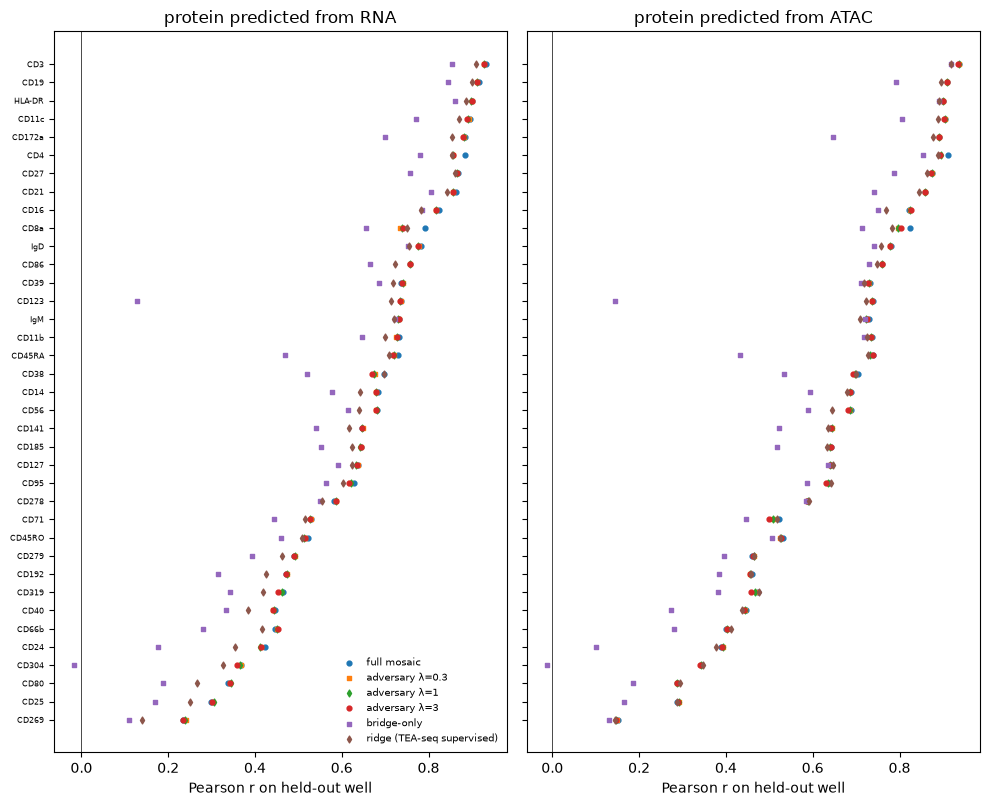

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 0.18 * len(adt_names) + 1.5), sharey=True)
order = per_protein[("full mosaic", "rna")].sort_values().index
for ax, src in zip(axes, ("rna", "atac")):
    for i, (name, _) in enumerate([k for k in per_protein if k[1] == src]):
        ax.scatter(per_protein[(name, src)].loc[order], np.arange(len(order)), s=12, label=name,
                   marker="osd"[i % 3])
    ax.set_yticks(range(len(order)), order, fontsize=6)
    ax.axvline(0, c="k", lw=0.5)
    ax.set(xlabel="Pearson r on held-out well", title=f"protein predicted from {src.upper()}")
axes[0].legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

If the bridge-only model's ATAC → protein correlations approach the full model's, RNA is an effective
bridge between chromatin and protein for these markers; proteins where it falls far short are
candidates for which chromatin carries information that RNA does not transmit (or where the
CITE-seq and TEA-seq antibody panels disagree).

## 5. The joint atlas

We embed held-out cells of all three cohorts. Each cohort is encoded from its RNA (the modality they
share), which makes cohorts comparable; `stack_embeddings` stacks them into one AnnData. For every
model, three numbers describe the atlas:

- **cohort mixing**: the fraction of each cell's 30 nearest neighbors that come from another cohort,
  next to the value expected if cohorts were perfectly mixed given their sizes;
- **label agreement**: CITE-seq cells carry the Hao et al. `celltype.l2` annotation, which a k-NN
  classifier on CITE-seq training cells transfers to the other cohorts. The Multiome file has its own
  annotation, made by Seurat label transfer from the same Hao reference, so for Multiome cells we can
  measure how often the two agree (`LABEL_MAP` translates the Multiome names; check it);
- the same agreement **balanced** over Multiome cell types, so that small populations count.

Good mixing is only useful if cell types stay intact: a model that mixes cohorts by blurring cell types
would raise mixing and lower agreement.

**How much cohort information is left?** Mixing counts neighbors; a more direct measure is whether a fresh
classifier (logistic regression, 5-fold cross-validated, balanced accuracy) can still tell the cohort from a
cell's RNA embedding. Chance is 1/3. An adversary that works drives this toward chance; one that is only
fooled drives down its own head's accuracy but leaves this one high.

**Why not simply raise the adversary strength?** In an earlier run, going from λ = 0.3 to 3 moved validation
mixing only from 0.079 to 0.089 while label agreement fell from 0.77 to as low as 0.63: a stronger adversary
removed cell-type structure faster than cohort structure. The input-side change above (consensus genes) is
the first thing to try; a batch covariate in the decoder, as in conditional VAEs, would be the principled
model-side remedy.

**Choosing the model.** The same numbers, plus ATAC → protein accuracy on the TEA-seq *validation*
wells, are computed on validation cells. Among the models whose validation label agreement and protein
accuracy are within `MAX_AGREEMENT_DROP` and `MAX_ACCURACY_DROP` of the model without an adversary, the
one with the most cohort mixing is used from here on. Choosing on validation cells keeps the held-out
TEA-seq well and the test cells untouched by the choice.

validation cells:


,cohort mixing,mixing if perfectly mixed,label agreement (Multiome),balanced label agreement,Multiome cells with a mapped label,"cohort predictable (balanced acc., chance 0.33)",ATAC→protein median r (TEA-seq val),passes rule
full mosaic,0.076,0.586,0.818,0.733,1.0,0.364,0.704,True
adversary λ=0.3,0.121,0.586,0.654,0.692,1.0,0.369,0.705,False
adversary λ=1,0.126,0.586,0.656,0.687,1.0,0.336,0.703,False
adversary λ=3,0.185,0.586,0.616,0.686,1.0,0.314,0.705,False


model used below: full mosaic (chosen on validation cells)


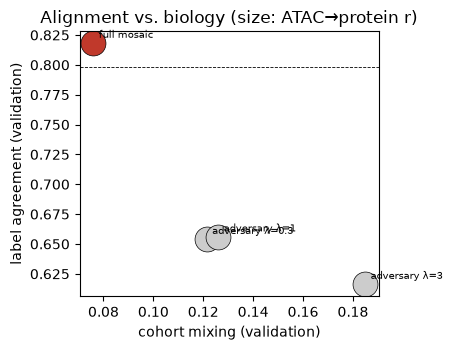

test cells:


,cohort mixing,mixing if perfectly mixed,label agreement (Multiome),balanced label agreement,Multiome cells with a mapped label
full mosaic,0.054,0.549,0.800,0.705,1.0
adversary λ=0.3,0.084,0.549,0.655,0.646,1.0
adversary λ=1,0.087,0.549,0.656,0.635,1.0
adversary λ=3,0.128,0.549,0.619,0.632,1.0


In [14]:
cite_labels = cite["rna"].obs[CITE_LABEL].astype(str)
orig_by_split = {k: mult["rna"].obs["cell_type"].astype(str).iloc[mult_idx[k]].to_numpy() for k in ("val", "test")}
multiome_orig = orig_by_split["test"]


def build_atlas(model, split="test"):
    atlas = stack_embeddings(model, [(c, "rna", data[c][split]["rna"]) for c in data], device=device)
    atlas.obs["cohort"] = atlas.obs["cohort"].astype(str)
    z_ref = encode_adata(model, data["CITE-seq"]["train"]["rna"], modality="rna", device=device, latent="modality_mean")
    y_ref = cite_labels.iloc[cite_idx["train"]].to_numpy()
    transferred = pd.Series(index=atlas.obs_names, dtype=object)
    for c in data:
        sel = (atlas.obs["cohort"] == c).to_numpy()
        if c == "CITE-seq":
            transferred[sel] = cite_labels.iloc[cite_idx[split]].to_numpy()
        else:
            transferred[sel] = label_transfer_knn(z_ref, y_ref, atlas.obsm["X_univi"][sel], k=15)[0]
    atlas.obs[f"{CITE_LABEL} (transferred)"] = pd.Categorical(transferred.astype(str))
    return atlas


def atlas_metrics(atlas, multiome_orig=multiome_orig):
    mix = compute_modality_mixing(atlas.obsm["X_univi"], atlas.obs["cohort"].to_numpy(), k=30)
    frac = atlas.obs["cohort"].value_counts(normalize=True)
    sel = (atlas.obs["cohort"] == "Multiome").to_numpy()
    pred = atlas.obs[f"{CITE_LABEL} (transferred)"].astype(str).to_numpy()[sel]
    mapped = np.array([o in LABEL_MAP for o in multiome_orig])
    hit = np.array([p in LABEL_MAP.get(o, []) for o, p in zip(multiome_orig, pred)])
    per_type = pd.Series(hit[mapped]).groupby(multiome_orig[mapped]).mean() if mapped.any() else pd.Series(dtype=float)
    return {"cohort mixing": mix, "mixing if perfectly mixed": 1 - (frac ** 2).sum(),
            "label agreement (Multiome)": hit[mapped].mean() if mapped.any() else np.nan,
            "balanced label agreement": per_type.mean() if len(per_type) else np.nan,
            "Multiome cells with a mapped label": mapped.mean()}


def protein_r(model, split):
    part = data["TEA-seq"][split]
    pred = cross_modal_predict(model, part["atac"], src_mod="atac", tgt_mod="adt", device=device)
    return float(np.nanmedian(pearson_corr_per_feature(dense(part["adt"].X), pred)))


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


def cohort_predictability(atlas):
    y = atlas.obs["cohort"].to_numpy()
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    return float(cross_val_score(clf, atlas.obsm["X_univi"], y, cv=5, scoring="balanced_accuracy").mean())


candidates = [name for name in models if name != "bridge-only"]
val_atlases = {name: build_atlas(models[name], "val") for name in candidates}
val = pd.DataFrame({name: {**atlas_metrics(val_atlases[name], orig_by_split["val"]),
                           "cohort predictable (balanced acc., chance 0.33)": cohort_predictability(val_atlases[name]),
                           "ATAC→protein median r (TEA-seq val)": protein_r(models[name], "val")}
                    for name in candidates}).T
base = val.loc["full mosaic"]
ok = ((val["label agreement (Multiome)"] >= base["label agreement (Multiome)"] - MAX_AGREEMENT_DROP)
      & (val["ATAC→protein median r (TEA-seq val)"] >= base["ATAC→protein median r (TEA-seq val)"] - MAX_ACCURACY_DROP))
chosen = val.loc[ok, "cohort mixing"].idxmax()
val["passes rule"] = ok
print("validation cells:")
display(val.round(3))
if ATLAS_MODEL is None:
    ATLAS_MODEL = chosen
print("model used below:", ATLAS_MODEL, "(chosen on validation cells)" if ATLAS_MODEL == chosen else "(set by hand)")

fig, ax = plt.subplots(figsize=(4.6, 3.6))
for name, r in val.iterrows():
    ax.scatter(r["cohort mixing"], r["label agreement (Multiome)"], s=40 + 400 * max(r["ATAC→protein median r (TEA-seq val)"], 0),
               c="#c0392b" if name == ATLAS_MODEL else ("0.35" if r["passes rule"] else "0.8"), edgecolor="k", lw=0.5)
    ax.annotate(name, (r["cohort mixing"], r["label agreement (Multiome)"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axhline(base["label agreement (Multiome)"] - MAX_AGREEMENT_DROP, ls="--", c="k", lw=0.6)
ax.set(xlabel="cohort mixing (validation)", ylabel="label agreement (validation)",
       title="Alignment vs. biology (size: ATAC→protein r)")
plt.tight_layout()
plt.show()

print("test cells:")
atlases = {name: build_atlas(models[name]) for name in candidates}
display(pd.DataFrame({name: atlas_metrics(a) for name, a in atlases.items()}).T.round(3))

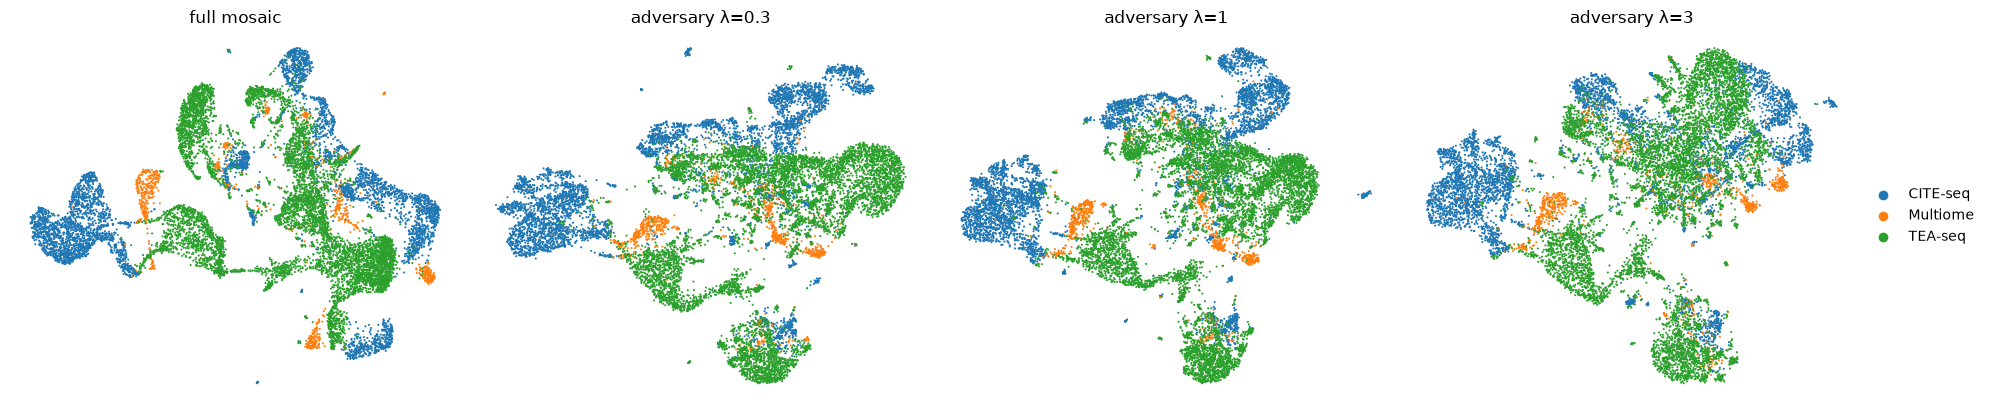

In [15]:
fig, axes = plt.subplots(1, len(atlases), figsize=(5 * len(atlases), 4.2), squeeze=False)
for ax, (name, a) in zip(axes[0], atlases.items()):
    sc.pp.neighbors(a, use_rep="X_univi", n_neighbors=30)
    sc.tl.umap(a, random_state=0)
    sc.pl.umap(a, color="cohort", ax=ax, show=False, title=name, legend_loc="right margin" if ax is axes[0][-1] else "none",
               frameon=False)
plt.tight_layout()
plt.show()

### Transferred labels in the chosen model

For Multiome cells, the heatmap shows, for each original label, which transferred labels its cells
receive.

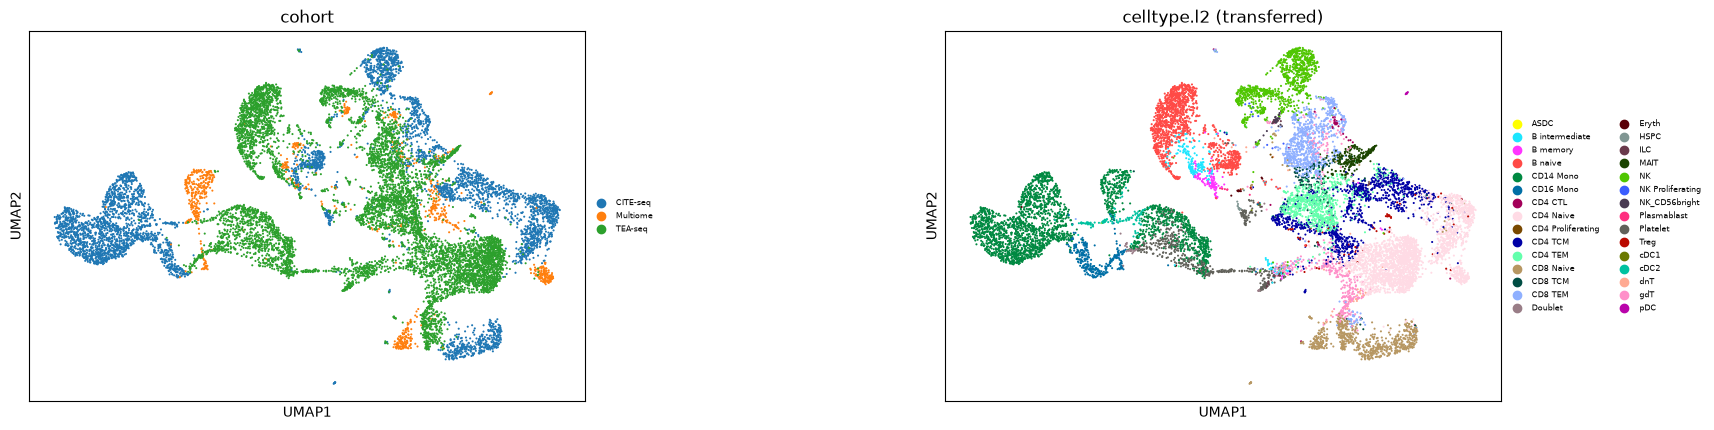

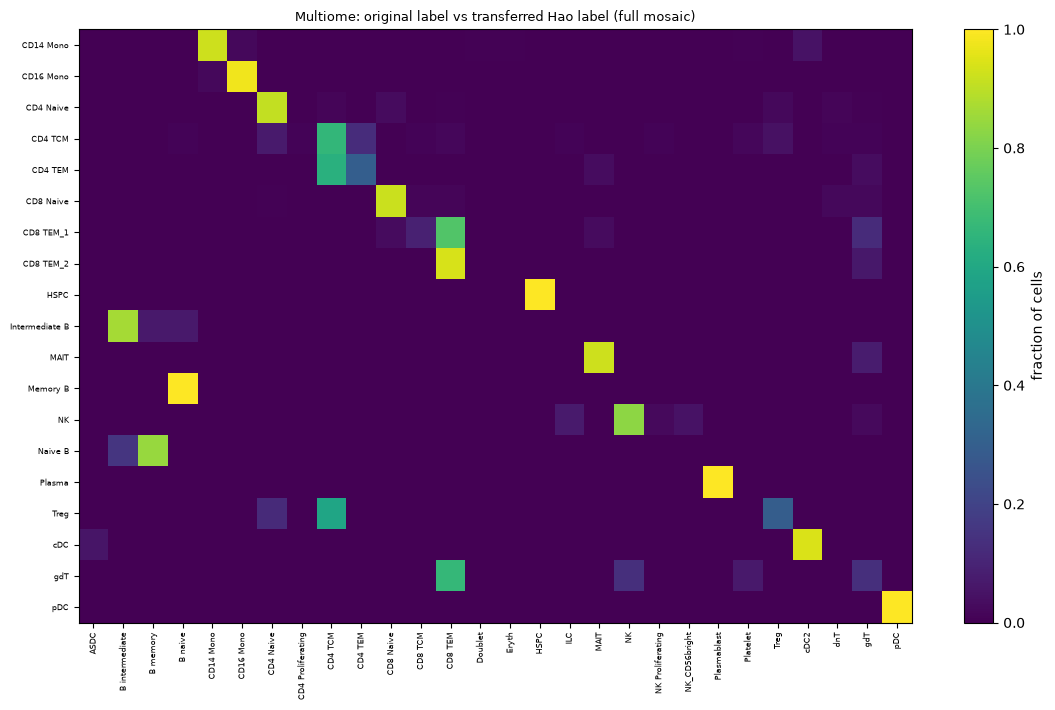

In [16]:
model = models[ATLAS_MODEL]
atlas = atlases[ATLAS_MODEL]
sc.pl.umap(atlas, color=["cohort", f"{CITE_LABEL} (transferred)"], wspace=0.5, legend_fontsize=6)
sel = (atlas.obs["cohort"] == "Multiome").to_numpy()
ct = pd.crosstab(pd.Series(multiome_orig, name="Multiome cell_type"),
                 pd.Series(atlas.obs[f"{CITE_LABEL} (transferred)"].to_numpy()[sel], name="transferred"),
                 normalize="index")
fig, ax = plt.subplots(figsize=(0.3 * ct.shape[1] + 3, 0.3 * ct.shape[0] + 1.5))
im = ax.imshow(ct.to_numpy(), cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(ct.shape[1]), ct.columns, rotation=90, fontsize=6)
ax.set_yticks(range(ct.shape[0]), ct.index, fontsize=6)
plt.colorbar(im, ax=ax, label="fraction of cells")
ax.set_title(f"Multiome: original label vs transferred Hao label ({ATLAS_MODEL})", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Inside the latent space

The held-out TEA-seq well has all three modalities for every cell, so it shows how the latent space
treats the same cell seen through different assays. Cells are labeled with their transferred Hao label.

In [17]:
held = data["TEA-seq"]["test"]
tea_block = atlas.obs["cohort"] == "TEA-seq"
tea_labels = pd.Series(atlas.obs.loc[tea_block, f"{CITE_LABEL} (transferred)"].astype(str).to_numpy(),
                       index=atlas.obs.loc[tea_block, "cell_id"].astype(str).to_numpy()).reindex(held["rna"].obs_names.astype(str))
tea_labels = tea_labels.fillna("unlabeled").to_numpy()
mods = ["rna", "adt", "atac"]


def posteriors(model, part):
    model.eval()
    out = {}
    with torch.no_grad():
        for m in mods:
            mus, vs = [], []
            for s_ in range(0, part[m].n_obs, 2048):
                x = torch.as_tensor(dense(part[m].X[s_:s_ + 2048]), dtype=torch.float32, device=device)
                mu, lv = model.encode_modalities({m: x})
                mus.append(mu[m].cpu().numpy())
                vs.append(lv[m].exp().cpu().numpy())
            out[m] = (np.concatenate(mus), np.concatenate(vs))
    return out


post = posteriors(model, held)

### One cell, three views

The RNA, protein and ATAC embeddings of the held-out cells in one layout. If the modalities are well
aligned, a cell's three points land together; the grey lines join the three points of
`N_LINKED_CELLS` random cells.

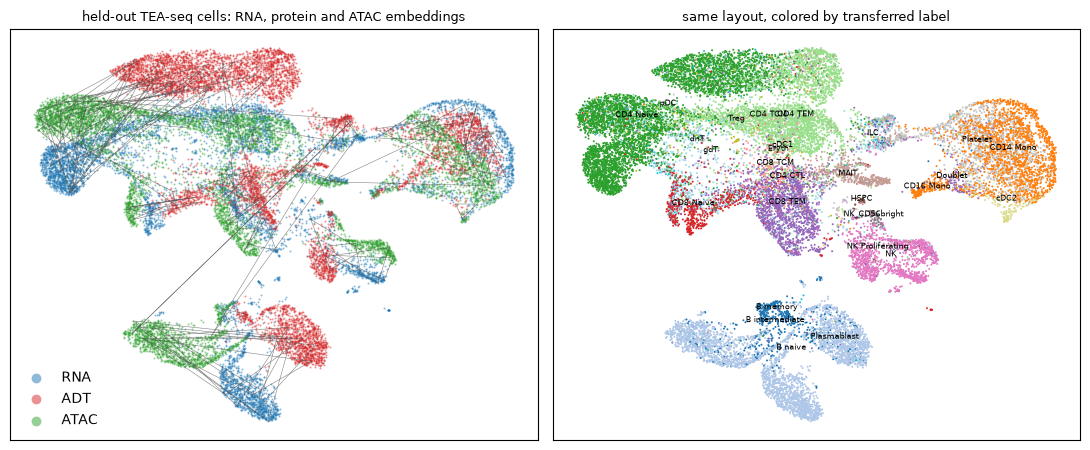

In [18]:
joint = ad.AnnData(np.concatenate([post[m][0] for m in mods]).astype(np.float32),
                   obs=pd.DataFrame({"modality": np.repeat(mods, held["rna"].n_obs),
                                     "cell_type": np.tile(tea_labels, len(mods))},
                                    index=[f"{m}:{i}" for m in mods for i in range(held["rna"].n_obs)]))
sc.pp.neighbors(joint, n_neighbors=30, use_rep="X")
sc.tl.umap(joint, random_state=0)
U = joint.obsm["X_umap"].reshape(len(mods), held["rna"].n_obs, 2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
colors = {"rna": "#1f77b4", "adt": "#d62728", "atac": "#2ca02c"}
for m_i, m in enumerate(mods):
    axes[0].scatter(U[m_i, :, 0], U[m_i, :, 1], s=2, c=colors[m], alpha=0.5, lw=0, label=m.upper())
for i in np.random.default_rng(0).choice(held["rna"].n_obs, min(N_LINKED_CELLS, held["rna"].n_obs), replace=False):
    axes[0].plot(U[[0, 1, 2, 0], i, 0], U[[0, 1, 2, 0], i, 1], c="0.3", lw=0.4, alpha=0.7)
axes[0].legend(markerscale=5, frameon=False)
axes[0].set_title("held-out TEA-seq cells: RNA, protein and ATAC embeddings", fontsize=9)
types_j = pd.Categorical(joint.obs["cell_type"])
axes[1].scatter(joint.obsm["X_umap"][:, 0], joint.obsm["X_umap"][:, 1], s=2, c=types_j.codes, cmap="tab20", lw=0)
for t_i, t in enumerate(types_j.categories):
    xy = np.median(joint.obsm["X_umap"][types_j.codes == t_i], axis=0)
    axes[1].annotate(t, xy, fontsize=6, ha="center")
axes[1].set_title("same layout, colored by transferred label", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### Where do the modalities disagree?

For every held-out cell, the distance between its posterior means in each pair of modalities, summarized
by cell type (median). Small values mean the two assays place the cell at the same point; a cell type
with large RNA–protein distances is one whose surface phenotype the model cannot fully infer from RNA,
and the reverse.

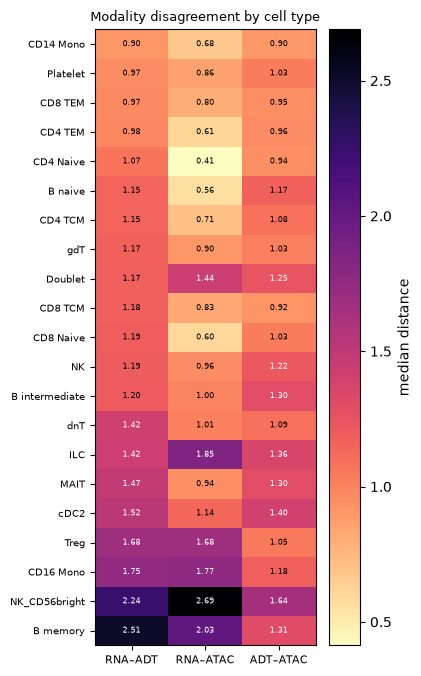

In [19]:
dist = pd.DataFrame({f"{a.upper()}–{b.upper()}": np.linalg.norm(post[a][0] - post[b][0], axis=1)
                     for a, b in [("rna", "adt"), ("rna", "atac"), ("adt", "atac")]}, index=tea_labels)
counts_t = pd.Series(tea_labels).value_counts()
keep_t = counts_t[counts_t >= 20].index
dmed = dist.groupby(level=0).median().loc[keep_t].sort_values("RNA–ADT")
fig, ax = plt.subplots(figsize=(4.2, 0.26 * len(dmed) + 1.4))
im = ax.imshow(dmed.to_numpy(), cmap="magma_r", aspect="auto")
ax.set_xticks(range(3), dmed.columns, fontsize=8)
ax.set_yticks(range(len(dmed)), dmed.index, fontsize=7)
for i in range(dmed.shape[0]):
    for j in range(3):
        ax.text(j, i, f"{dmed.iat[i, j]:.2f}", ha="center", va="center", fontsize=6,
                color="w" if dmed.iat[i, j] > dmed.to_numpy().mean() else "k")
plt.colorbar(im, ax=ax, label="median distance")
ax.set_title("Modality disagreement by cell type", fontsize=9)
plt.tight_layout()
plt.show()

### Who is the expert?

UniVI combines the modality posteriors by precision weighting (a product of Gaussians), so the fused mean
leans toward whichever modality is most confident in each latent dimension. Averaged over dimensions the
three precisions are nearly equal here, so a more direct question is asked: **how far does a cell's fused
embedding move when one modality is left out?** A modality that steers the fused embedding moves it a
lot when removed. The bars show each modality's share of that movement, averaged per cell type (the dashed
line is an equal split).

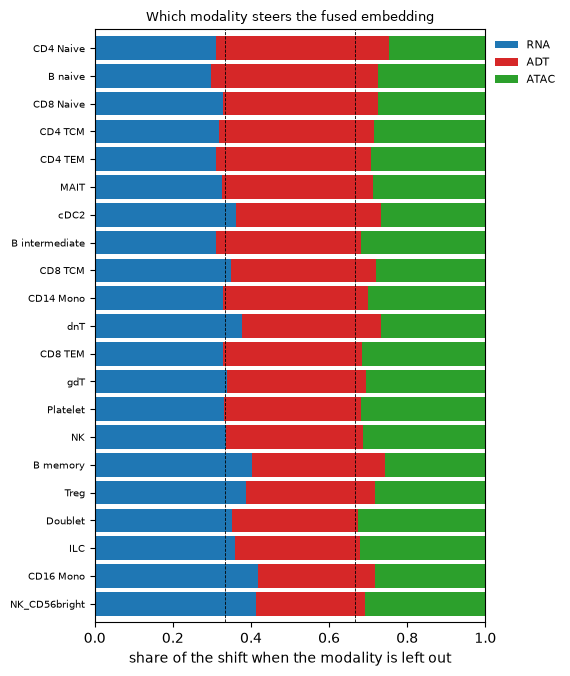

mean precision share over all cells: {'RNA': 0.338, 'ADT': 0.331, 'ATAC': 0.331}


In [20]:
x_all = {m: torch.as_tensor(dense(held[m].X), dtype=torch.float32, device=device) for m in mods}
model.eval()
with torch.no_grad():
    mu_all = model.encode_fused(x_all, use_mean=True)[0]
    influence = {m: (mu_all - model.encode_fused({k: v for k, v in x_all.items() if k != m}, use_mean=True)[0])
                 .norm(dim=1).cpu().numpy() for m in mods}
infl = pd.DataFrame({m.upper(): influence[m] for m in mods}, index=tea_labels)
infl_share = infl.div(infl.sum(axis=1), axis=0)
mshare = infl_share.groupby(level=0).mean().loc[keep_t].sort_values("ADT")
ax = mshare.plot.barh(stacked=True, figsize=(5.8, 0.26 * len(mshare) + 1.4), width=0.85,
                      color=[colors[m] for m in mods])
for x_ in (1 / 3, 2 / 3):
    ax.axvline(x_, c="k", lw=0.6, ls="--")
ax.set(xlabel="share of the shift when the modality is left out", ylabel="", xlim=(0, 1))
ax.tick_params(axis="y", labelsize=7)
ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1, 1))
ax.set_title("Which modality steers the fused embedding", fontsize=9)
plt.tight_layout()
plt.show()
prec = {m: 1.0 / (post[m][1] + 1e-12) for m in mods}
print("mean precision share over all cells:",
      {m.upper(): round(float((prec[m] / sum(prec.values())).mean()), 3) for m in mods})

### A walk through the latent space

The fused embedding is continuous, so points between two cell types can be decoded too. Starting at the
centroid of one cell type (`TRAVERSE[0]`) and walking in a straight line to another (`TRAVERSE[1]`), the
protein decoder predicts the surface phenotype along the way. The proteins shown are those that change
most between the ends. Hollow markers are the **observed** mean protein of each type. Decoded values are
shrunk toward the average (decoding a centroid gives a typical cell, not an extreme one), so compare the
**direction and relative size** of the changes; the printed correlation does that for every protein on
the panel. (If the named types are missing, the two most common types are used.)

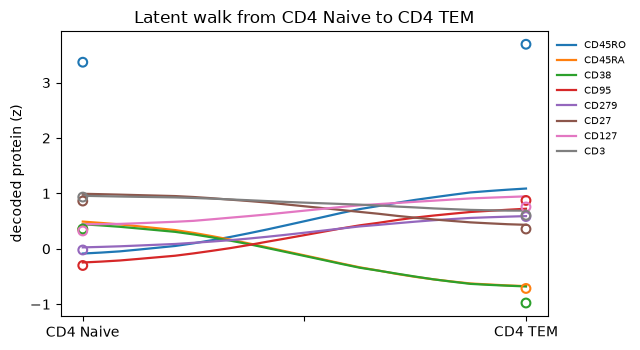

decoded vs observed change CD4 Naive -> CD4 TEM, across all 37 proteins: Pearson r = 0.92; same direction for 100% of the proteins shown


In [21]:
fused_mu = None
model.eval()
with torch.no_grad():
    fused_mu = model.encode_fused({m: torch.as_tensor(dense(held[m].X), dtype=torch.float32, device=device) for m in mods},
                                  use_mean=True)[0].cpu().numpy()
pair = [t for t in TRAVERSE if (tea_labels == t).sum() >= 10]
if len(pair) < 2:
    pair = list(pd.Series(tea_labels[tea_labels != "unlabeled"]).value_counts().index[:2])
a_t, b_t = pair[:2]
za, zb = fused_mu[tea_labels == a_t].mean(0), fused_mu[tea_labels == b_t].mean(0)
steps = np.linspace(0, 1, 25)
path = np.stack([(1 - t) * za + t * zb for t in steps])
dec = pd.DataFrame(decode_from_latent(model, path.astype(np.float32), device=device)["adt"], columns=adt_names)
change = (dec.iloc[-1] - dec.iloc[0]).abs().sort_values(ascending=False)
show_p = list(change.index[:8])
obs_adt_held = pd.DataFrame(dense(held["adt"].X), columns=adt_names)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for i, prot in enumerate(show_p):
    col = plt.cm.tab10(i % 10)
    ax.plot(steps, dec[prot], c=col, lw=1.6, label=prot)
    ax.scatter([0, 1], [obs_adt_held.loc[tea_labels == a_t, prot].mean(), obs_adt_held.loc[tea_labels == b_t, prot].mean()],
               facecolor="none", edgecolor=col, s=40, lw=1.5, zorder=3)
ax.set_xticks([0, 0.5, 1], [a_t, "", b_t])
ax.set(ylabel="decoded protein (z)", title=f"Latent walk from {a_t} to {b_t}")
ax.legend(fontsize=7, frameon=False, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
obs_change = obs_adt_held.loc[tea_labels == b_t].mean() - obs_adt_held.loc[tea_labels == a_t].mean()
dec_change = dec.iloc[-1] - dec.iloc[0]
agree = np.corrcoef(obs_change, dec_change)[0, 1]
same_sign = float((np.sign(obs_change[show_p]) == np.sign(dec_change[show_p])).mean())
print(f"decoded vs observed change {a_t} -> {b_t}, across all {len(adt_names)} proteins: Pearson r = {agree:.2f}; "
      f"same direction for {same_sign:.0%} of the proteins shown")

## 7. Virtual CITE-seq for the Multiome cells

The Multiome cells were never stained with antibodies, but the model has a protein decoder. Encoding
each Multiome cell from **both** its RNA and ATAC (precision-weighted fusion) and decoding protein
gives a predicted surface phenotype. The values are in the ADT model space (per-cohort z-scored CLR),
so compare them across cell types rather than reading them as absolute abundance. Section 4 shows how
accurate such predictions were on cells where protein was measured.

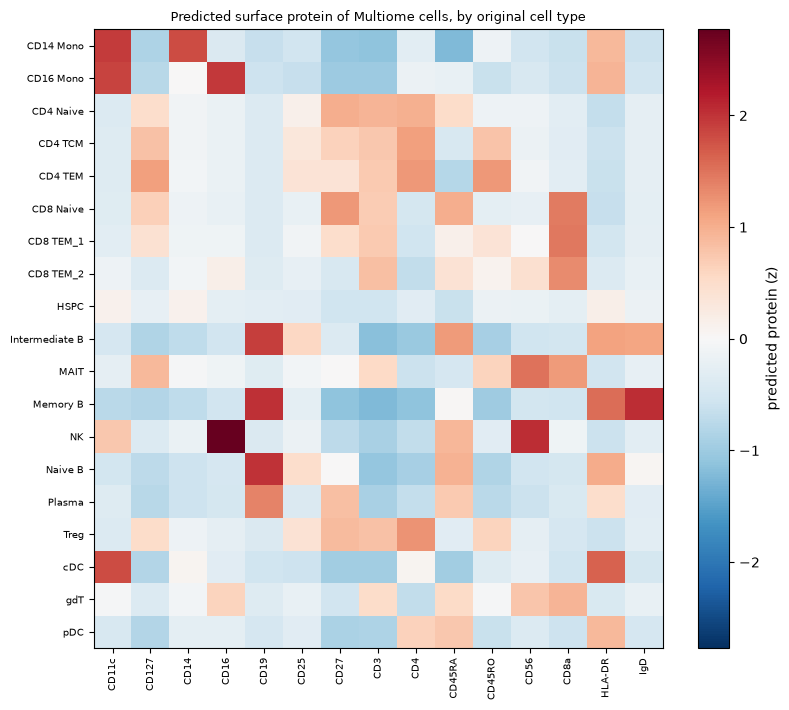

In [22]:
mt = data["Multiome"]["test"]
model.eval()
with torch.no_grad():
    mu = model.encode_fused({m: torch.as_tensor(dense(a.X), dtype=torch.float32, device=device)
                             for m, a in mt.items()}, use_mean=True)[0].cpu().numpy()
virtual = decode_from_latent(model, mu, device=device)["adt"]
virtual = pd.DataFrame(virtual, index=mt["rna"].obs_names, columns=adt_names)
by_type = virtual.groupby(mt["rna"].obs["cell_type"].astype(str).to_numpy()).mean()
show = [m for m in by_type.columns if norm_marker(m) in {"CD3", "CD4", "CD8", "CD8A", "CD19", "CD14", "CD16",
                                                         "CD56", "CD11C", "HLADR", "CD45RA", "CD45RO", "CD27",
                                                         "IGD", "CD127", "CD25"}] or list(by_type.columns[:16])
fig, ax = plt.subplots(figsize=(0.35 * len(show) + 3, 0.3 * len(by_type) + 1.5))
vals = by_type[show].to_numpy()
lim = np.abs(vals).max() or 1.0
im = ax.imshow(vals, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(show)), show, rotation=90, fontsize=7)
ax.set_yticks(range(len(by_type)), by_type.index, fontsize=7)
plt.colorbar(im, ax=ax, label="predicted protein (z)")
ax.set_title("Predicted surface protein of Multiome cells, by original cell type", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Save the atlas

The stacked embedding with transferred labels goes to an `.h5ad` file, and the model, with every fitted
transform, to a reference bundle. The bundle's metadata records the antibody panel and the cohort
splits, so the atlas can be rebuilt and new cells mapped with the same transforms.

In [23]:
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
atlas.write_h5ad(out_dir / "pbmc_mosaic_atlas_test_cells.h5ad")
save_reference(out_dir / "pbmc_mosaic_reference", model,
               preprocessors={"per_cohort": preps, "atac": atac_prep, "genes": genes, "adt_panel": panel},
               metadata={"cohorts": list(data), "tea_holdout": TEA_HOLDOUT, "cite_label": CITE_LABEL,
                         "per_cohort_scaling": PER_COHORT_SCALING, "atlas_model": ATLAS_MODEL,
                         "splits": {"cite_obs": {k: cite["rna"].obs_names[v].tolist() for k, v in cite_idx.items()},
                                    "multiome_obs": {k: mult["rna"].obs_names[v].tolist() for k, v in mult_idx.items()},
                                    "tea_obs": {k: tea["rna"].obs_names[v].tolist() for k, v in tea_idx.items()}}})
print("saved to", out_dir)

saved to univi_outputs


## What to try next

- **Where does the bridge break?** Rank antibodies by the gap between the full and bridge-only model
  (Section 4) and look for shared biology (e.g. activation markers with little transcript support).
- **Scaling choice.** Re-run with `PER_COHORT_SCALING = False` and compare cohort mixing and the
  held-out protein correlations.
- **Adversary strength.** The validation plot in Section 5 shows the trade-off between mixing and cell-type
  agreement across `ADV_LAMBDAS`; widen the range or start the adversary earlier (`ADV_WARMUP`) if every
  strength sits at one end of it, and compare the held-out table in Section 4 each time.
- **More modalities.** The AML mosaic (`aml_mosaic`) and the bridge cohorts (`pbmc_multiome_bridge`)
  follow the same pattern with RNA-only, ATAC-only or protein-only cohorts: add a loader per cohort.